# Predicting Short-Horizon SPY Returns Using Options Market Signals



## Research question:

**Do simple signals extracted from the SPY options market contain information about subsequent one-day SPY returns, and does their predictive relationship vary with the return horizon?**

This project studies four options-derived signals:

1.   near-30-day at-the-money implied volatility
2.   the daily change in ATM implied volatility
3.   put/call volume ratio
4.   25-delta volatility skew

I evaluate these signals at next-day and five-day return horizons using chronological expanding-window validation. The objective is not to maximize backtest performance through extensive feature or model selection, but to test a small set of economically motivated hypotheses while avoiding look-ahead bias and comparing forecasts against a simple zero-return benchmark.

## Summary:

The results show limited out-of-sample predictability at the next-day horizon and stronger apparent performance for overlapping five-day returns. However, the five-day improvement weakens substantially when the analysis is repeated using non-overlapping return windows, indicating sensitivity to target construction. Adding volatility skew provides some incremental information at the five-day horizon but does not establish robust out-of-sample return predictability.

# Data Loading

We obtained our SPY options price data in 2024 and the underlying SPY price from 1999 to 2025 through the following github repository.

In [ ]:
!git clone --depth 1 https://github.com/anahatsingh-ui/options-dataset-hist.git

We load the options price and stock price into two pandas dataframes, called


*   options
*   underlying

We load a few lines of options and underlying to get a sense of all the information included in the two dataframes.


In [192]:
import pandas as pd

options = pd.read_parquet("options-dataset-hist/spy/options_2024.parquet")
underlying = pd.read_parquet("options-dataset-hist/spy/underlying_prices.parquet")

print(options.shape)
display(options.head())
display(underlying.head())

(2292800, 21)


,contract_id,symbol,expiration,strike,type,last,mark,bid,bid_size,ask,...,volume,open_interest,date,implied_volatility,delta,gamma,theta,vega,rho,in_the_money
0,SPY240102C00402000,SPY,2024-01-02,402.0,call,69.97,70.77,70.68,100,70.85,...,130,1,2024-01-02,1.25387,0.99382,0.00056,-0.32882,0.00432,0.01093,0
1,SPY240102P00402000,SPY,2024-01-02,402.0,put,0.02,0.01,0.00,0,0.01,...,0,303,2024-01-02,1.03924,-0.00132,0.00017,-0.05582,0.00108,-0.00002,0
2,SPY240102C00403000,SPY,2024-01-02,403.0,call,68.97,69.78,69.68,100,69.89,...,9,0,2024-01-02,1.25387,0.99313,0.00062,-0.35558,0.00474,0.01095,0
3,SPY240102P00403000,SPY,2024-01-02,403.0,put,0.01,0.01,0.00,0,0.01,...,1,8,2024-01-02,1.02949,-0.00140,0.00018,-0.05839,0.00114,-0.00002,0
4,SPY240102C00404000,SPY,2024-01-02,404.0,call,68.64,68.77,68.68,100,68.85,...,1,1,2024-01-02,1.21485,0.99383,0.00058,-0.32053,0.00431,0.01099,0


,id,symbol,date,open,high,low,close,adjusted_close,volume,dividend_amount,split_coefficient,created_at
0,1,SPY,1999-11-01,136.500000,137.000000,135.562500,135.562500,85.371458,4006500,0.0,1.0,2025-12-15 15:56:25
1,2,SPY,1999-11-02,135.968704,137.250000,134.593704,134.593704,84.761351,6516900,0.0,1.0,2025-12-15 15:56:25
2,3,SPY,1999-11-03,136.000000,136.375000,135.125000,135.500000,85.332098,7222300,0.0,1.0,2025-12-15 15:56:25
3,4,SPY,1999-11-04,136.750000,137.359299,135.765594,136.531204,85.981506,7907500,0.0,1.0,2025-12-15 15:56:25
4,5,SPY,1999-11-05,138.625000,139.109299,136.781204,137.875000,86.827771,7431500,0.0,1.0,2025-12-15 15:56:25


A brief inspection of the data tells us that

*   Options price data is available from 2024-01-02 to 2024-12-31
*   Underlying stock price data is available from 1999-11-01 to 2025-12-12



In [193]:
print("Option dates:",options["date"].min(),"to", options["date"].max())
print("Underlying dates:", underlying["date"].min(), "to", underlying["date"].max())


Option dates: 2024-01-02 to 2024-12-31
Underlying dates: 1999-11-01 to 2025-12-12


# Feature Engineering
In this section, we construct the four options-derived features.



## Near-30-Day ATM Implied Volatility
Implied volatility (IV) summarizes the volatility embedded in option prices. I use near-30-day at-the-money (ATM) IV as a measure of the market's current pricing of uncertainty over an approximately one-month horizon.
For each trading date \(t\):
1. Compute days to expiration (DTE) for every available option expiration.
2. Select the expiration whose DTE is closest to 30 calendar days. If two expirations are equally close, select the shorter maturity.
3. Using the contemporaneous unadjusted SPY close $S_t$, select the strike $K_t^*$ closest to spot:
$$
   K_t^* := \arg\min_K |K-S_t|.
$$
4. Average the call and put implied volatilities at that strike:
$$
   IV_t=\frac{IV_{call,t}+IV_{put,t}}{2}.
$$
This produces a simple near-30-day ATM volatility measure. It is not an exact constant-maturity IV because I do not interpolate between adjacent expirations.

In [194]:
options["date"] = pd.to_datetime(options["date"])
options["expiration"] = pd.to_datetime(options["expiration"])
options["dte"] = (options["expiration"] - options["date"]).dt.days
options[["date", "expiration", "dte"]].head()
underlying["date"] = pd.to_datetime(underlying["date"])

In [196]:
def get_atm_iv(date, options, underlying):
    date = pd.Timestamp(date)

    # Options available on this date
    day = options[options["date"] == date].copy()

    # SPY closing price
    spy_price = underlying.loc[underlying["date"] == date, "close"].iloc[0]
    expirations = (day[["expiration", "dte"]].drop_duplicates().copy())

    expirations["distance_from_30"] = abs(expirations["dte"] - 30)

    expirations = expirations.sort_values(["distance_from_30", "dte"])

    target_expiration = expirations.iloc[0]["expiration"]
    chain = day[day["expiration"] == target_expiration].copy()
    strikes = chain["strike"].unique()
    atm_strike = min(strikes, key=lambda K: abs(K - spy_price))
    atm = chain[chain["strike"] == atm_strike]
    atm_iv = atm["implied_volatility"].mean()
    return {
        "date": date,
        "spy_price": spy_price,
        "expiration": target_expiration,
        "dte": (target_expiration - date).days,
        "atm_strike": atm_strike,
        "atm_iv": atm_iv
    }

In [197]:
dates = sorted(options["date"].unique())
results = []
for date in dates:
    try:
        results.append(
            get_atm_iv(date, options, underlying)
        )
    except (IndexError, ValueError):
        pass

atm_iv_daily = pd.DataFrame(results)
atm_iv_daily.head()
atm_iv_daily.describe()


,date,spy_price,expiration,dte,atm_strike,atm_iv
count,252,252.000000,252,252.000000,252.000000,252.000000
mean,2024-07-01 19:37:08.571428608,541.413849,2024-07-31 17:37:08.571428608,29.916667,541.400794,0.130516
min,2024-01-02 00:00:00,467.280000,2024-01-31 00:00:00,27.000000,467.500000,0.092925
25%,2024-04-02 18:00:00,512.712500,2024-05-03 00:00:00,29.000000,512.750000,0.112440
50%,2024-07-02 12:00:00,542.595000,2024-08-01 00:00:00,30.000000,542.250000,0.122195
75%,2024-10-01 06:00:00,570.275000,2024-10-31 06:00:00,31.000000,570.250000,0.142924
max,2024-12-31 00:00:00,607.810000,2025-01-31 00:00:00,32.000000,608.000000,0.292920
std,NaN,36.791905,NaN,1.384677,36.815250,0.026068


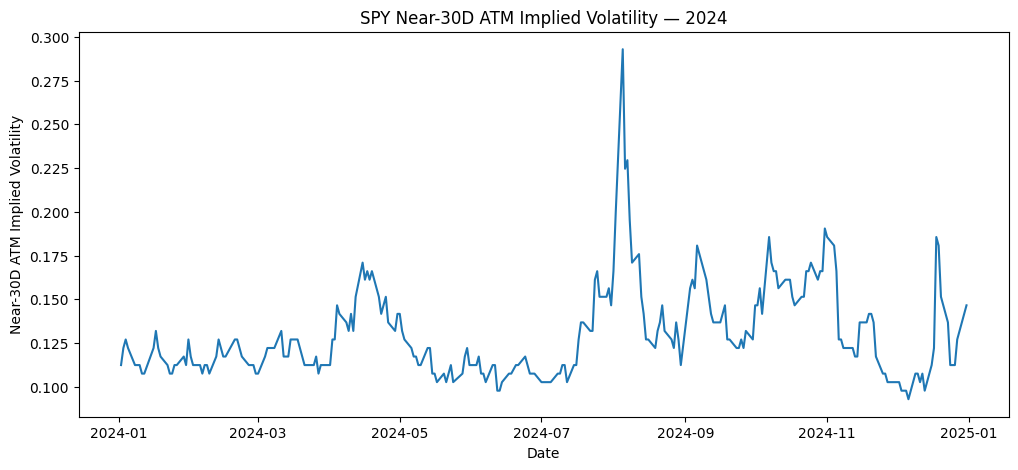

In [198]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    atm_iv_daily["date"],
    atm_iv_daily["atm_iv"]
)

plt.xlabel("Date")
plt.ylabel("Near-30D ATM Implied Volatility")
plt.title("SPY Near-30D ATM Implied Volatility — 2024")

plt.show()

Near-30-day ATM IV varies substantially over the year, with several periods of elevated implied volatility. The supplied IV values are discretized, producing some visible stair-stepping; this is treated as a limitation of the third-party dataset.

## Change in ATM IV

The IV level measures the current state of implied uncertainty, while its daily change captures the repricing of that uncertainty. They're related but not equivalent. In fact, we later found their correlation was only about 0.25, so empirically they aren't redundant either.

I therefore construct
$$
\Delta IV_t=IV_t-IV_{t-1}.
$$
The first observation is missing because no previous trading-day IV is available.

In [199]:
atm_iv_daily["atm_iv_change"] = (atm_iv_daily["atm_iv"].diff())
atm_iv_daily[["date", "atm_iv", "atm_iv_change"]].head(10)

,date,atm_iv,atm_iv_change
0,2024-01-02,0.11244,NaN
1,2024-01-03,0.12219,0.00975
2,2024-01-04,0.12707,0.00488
3,2024-01-05,0.12219,-0.00488
4,2024-01-08,0.11244,-0.00975
5,2024-01-09,0.11244,0.00000
6,2024-01-10,0.11244,0.00000
7,2024-01-11,0.10756,-0.00488
8,2024-01-12,0.10756,0.00000
9,2024-01-16,0.12219,0.01463


## Put/Call Volume Ratio

The put/call volume ratio (PCR) measures relative trading activity in put and call options:
$$
PCR_t=\frac{\text{Put Volume}_t}{\text{Call Volume}_t}.
$$
A larger value indicates greater put trading volume relative to call trading volume. However, PCR should not be interpreted mechanically as a bearish-sentiment measure because option volume can reflect hedging, spreads, volatility trades, and market-making activity.
Rather than aggregate all SPY options, I restrict the calculation to contracts with 8–60 days to expiration and absolute delta between 0.2 and 0.8. This excludes very short-dated contracts and very low/high-delta contracts, which represent distinct trading regimes and dominate aggregate option volume.

In [200]:
dte_bins = [0, 7, 30, 60, 90, float("inf")]
dte_labels = ["0-7", "8-30", "31-60", "61-90", ">90"]

options["dte_bucket"] = pd.cut(
    options["dte"],
    bins=dte_bins,
    labels= dte_labels,
    right=True,
    include_lowest=True
)

options["dte_bucket"].value_counts().sort_index()
volume_by_dte = (options.groupby("dte_bucket", observed=True)["volume"].sum())
volume_by_dte

,volume
dte_bucket,
0-7,1591422512
8-30,188639002
31-60,96111195
61-90,32677065
>90,47686375


Approximately 81% of total option volume occurs in contracts with 0–7 DTE. I exclude these contracts from the primary PCR specification so that the feature is not dominated by very short-dated option activity.

In [201]:
options["abs_delta"] = options["delta"].abs()
delta_bins = [0, 0.1, 0.2, 0.4, 0.6, 0.8, 1]

delta_labels = [
    "0-.10",
    ".10-.20",
    ".20-.40",
    ".40-.60",
    ".60-.80",
    ".80-1"
]

options["delta_bucket"] = pd.cut(
    options["abs_delta"],
    bins=delta_bins,
    labels=delta_labels,
    include_lowest=True
)
volume_by_delta = (
    options
    .groupby("delta_bucket", observed=True)["volume"]
    .sum()
)

volume_by_delta

,volume
delta_bucket,
0-.10,849587998
.10-.20,192980445
.20-.40,289274053
.40-.60,252062982
.60-.80,149601098
.80-1,223029573


Now we combine dte and delta filter, and construct the actual put/call ratio feature.

In [202]:
filtered_options = options[options["dte"].between(8, 60) & options["abs_delta"].between(0.2, 0.8)]
cp_volume_table = filtered_options.groupby(["date", "type"])["volume"].sum().unstack()
cp_volume_table["put_call_ratio"] = cp_volume_table["put"]/cp_volume_table["call"]
print(cp_volume_table["put_call_ratio"].describe())
cp_volume_table["put_call_ratio"].sort_values().head()
cp_volume_table["put_call_ratio"].sort_values(ascending=True).head()

count    252.000000
mean       1.229252
std        0.521162
min        0.499207
25%        0.864660
50%        1.121062
75%        1.430755
max        4.467517
Name: put_call_ratio, dtype: float64


,put_call_ratio
date,
2024-07-10,0.499207
2024-01-19,0.537487
2024-02-29,0.554273
2024-07-02,0.600854
2024-01-10,0.608873


The 8–60 DTE and $0.2\le|\Delta|\le0.8 $ filters are fixed modeling choices intended to define a reasonably liquid, non-extreme option universe; they are not selected by optimizing subsequent return-prediction performance.

## 25-Delta Volatility Skew

ATM implied volatility measures the overall level of option-implied uncertainty, but it does not capture whether downside and upside options are priced differently. To measure this asymmetry, I construct a near-30-day 25-delta volatility skew:
$$
Skew_t
=
IV_{\Delta\approx-0.25,t}^{put}
-
IV_{\Delta\approx+0.25,t}^{call}.
$$
For each trading day, I use the same near-30-day expiration methodology as for ATM IV. Within that expiration, I select the put whose delta is closest to \(-0.25\) and the call whose delta is closest to \(+0.25\).
Positive skew means that the selected downside put has higher implied volatility than the corresponding upside call. This may reflect asymmetric pricing of downside versus upside risk, but should not be interpreted mechanically as a directional market forecast.

In [203]:
def get_skew(date, options):
    date = pd.Timestamp(date)

    day = options[
        options["date"] == date
    ].copy()

    # Find the expiration closest to 30 DTE,
    # breaking ties in favor of shorter DTE
    expirations = (
        day[["expiration", "dte"]]
        .drop_duplicates()
        .copy()
    )

    expirations["distance_from_30"] = abs(expirations["dte"] - 30)
    expirations = expirations.sort_values(["distance_from_30", "dte"])
    target_expiration = expirations.iloc[0]["expiration"]

    chain = day[day["expiration"] == target_expiration].copy()

    calls = chain[chain["type"] == "call"]
    puts = chain[chain["type"] == "put"]

    # Closest to +0.25
    call_25 = calls.loc[(calls["delta"]-0.25).abs().idxmin()]

    # Closest to -0.25
    put_25 = puts.loc[(puts["delta"] + 0.25).abs().idxmin()]

    skew = put_25["implied_volatility"] - call_25["implied_volatility"]

    return {
        "date": date,
    "expiration": target_expiration,
    "call_strike": call_25["strike"],
    "call_delta": call_25["delta"],
    "call_iv": call_25["implied_volatility"],
    "put_strike": put_25["strike"],
    "put_delta": put_25["delta"],
    "put_iv": put_25["implied_volatility"],
    "skew": skew
    }

In [204]:
valid_dates = underlying[
    underlying["date"].dt.year == 2024
]["date"].unique()
skew_results = []

for date in valid_dates:
    result = get_skew(date, options)
    skew_results.append(result)

skew_daily = pd.DataFrame(skew_results)
skew_daily = skew_daily.sort_values("date").reset_index(drop=True)

Quality control checks:

In [205]:
skew_daily["skew"].describe()

,skew
count,252.000000
mean,0.039256
std,0.019078
min,-0.019510
25%,0.029260
50%,0.039020
75%,0.048780
max,0.126820


In [206]:
skew_daily["call_delta_error"] = (skew_daily["call_delta"] - 0.25).abs()
skew_daily["put_delta_error"] = (skew_daily["put_delta"] + 0.25).abs()
skew_daily[["call_delta_error", "put_delta_error"]].describe()

,call_delta_error,put_delta_error
count,252.000000,252.000000
mean,0.008554,0.003837
std,0.010687,0.003323
min,0.000060,0.000010
25%,0.002245,0.001672
50%,0.005065,0.003195
75%,0.008868,0.005257
max,0.062040,0.023020


The selected contracts are generally close to the target deltas of \(+0.25\) and \(-0.25\), supporting the use of the resulting series as an approximate 25-delta skew measure.

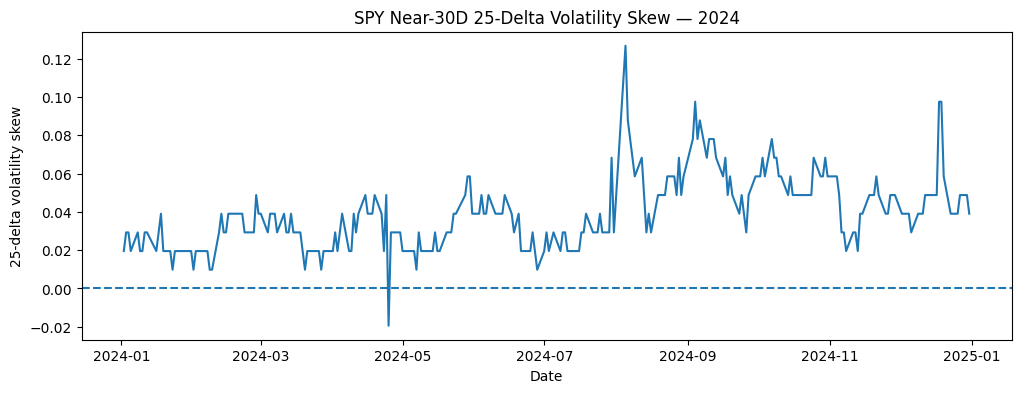

In [207]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(skew_daily["date"], skew_daily["skew"])
plt.axhline(0, linestyle="--")
plt.xlabel("Date")
plt.ylabel("25-delta volatility skew")
plt.title("SPY Near-30D 25-Delta Volatility Skew — 2024")
plt.show()

The skew is positive on most trading days, indicating that 25-delta puts generally carry higher implied volatility than comparable 25-delta calls. The series exhibits visible stair-stepping because the source dataset reports implied volatility on a relatively coarse grid. Despite this discretization, skew varies meaningfully over time.

# Target Construction and Modeling Dataset



## Prediction Target

The objective is to test whether option-market information observed on trading day \(t\) contains information about the subsequent SPY return. I define the prediction target as the next trading day's close-to-close return:
$$
r_{t+1}=\frac{P_{t+1}}{P_t}-1,
$$
where \(P_t\) is SPY's adjusted closing price.
Adjusted close is used for the return calculation because it accounts for distributions and stock splits, producing a more consistent measure of investment returns over time. In contrast, the contemporaneous unadjusted close is used when identifying ATM options because moneyness should be based on the actual underlying price observed on that date.

## Construct the target

In [208]:
spy = underlying.sort_values("date")[underlying["date"]>="2024-01-02"].copy()
spy["return"] = spy["adjusted_close"].pct_change()
spy["next_day_return"] = spy["return"].shift(-1)
spy["next_5d_return"] = (spy["adjusted_close"].shift(-5)/ spy["adjusted_close"]- 1)
spy["target_1d_end_date"] = spy["date"].shift(-1)
spy["target_5d_end_date"] = spy["date"].shift(-5)
spy.head(5)

,id,symbol,date,open,high,low,close,adjusted_close,volume,dividend_amount,split_coefficient,created_at,return,next_day_return,next_5d_return,target_1d_end_date,target_5d_end_date
6080,6081,SPY,2024-01-02,472.16,473.67,470.49,472.65,462.619009,123007793,0.0,1.0,2025-12-15 15:56:25,NaN,-0.008167,0.002602,2024-01-03,2024-01-09
6081,6082,SPY,2024-01-03,470.43,471.19,468.17,468.79,458.840929,103585866,0.0,1.0,2025-12-15 15:56:25,-0.008167,-0.003221,0.016575,2024-01-04,2024-01-10
6082,6083,SPY,2024-01-04,468.30,470.96,467.05,467.28,457.362976,84232169,0.0,1.0,2025-12-15 15:56:25,-0.003221,0.001370,0.019410,2024-01-05,2024-01-11
6083,6084,SPY,2024-01-05,467.49,470.44,466.43,467.92,457.989393,85553758,0.0,1.0,2025-12-15 15:56:25,0.001370,0.014276,0.018721,2024-01-08,2024-01-12
6084,6085,SPY,2024-01-08,468.43,474.75,468.30,474.60,464.527625,74879074,0.0,1.0,2025-12-15 15:56:25,0.014276,-0.001517,0.000695,2024-01-09,2024-01-16


## Merge the features

In [209]:
model_data = atm_iv_daily.merge(
    cp_volume_table[["put_call_ratio"]],
    on= "date",
    how= "inner"
)

model_data = model_data.merge(
    skew_daily[["date", "skew"]],
    on= "date",
    how="inner"
)
model_data = model_data.merge(
    spy[["date", "next_day_return", "next_5d_return",
         "target_1d_end_date", "target_5d_end_date"]],
    on="date",
    how="inner"
)
model_data = (
    model_data
    .sort_values("date")
    .reset_index(drop=True)
)

model_data.head()
print(model_data.shape)
print(model_data.isna().sum())
model_data = model_data.dropna().copy()


(252, 13)
date                  0
spy_price             0
expiration            0
dte                   0
atm_strike            0
atm_iv                0
atm_iv_change         1
put_call_ratio        0
skew                  0
next_day_return       0
next_5d_return        0
target_1d_end_date    0
target_5d_end_date    0
dtype: int64


In [210]:
cols = [
    "date",
    "atm_iv",
    "atm_iv_change",
    "put_call_ratio",
    "skew",
    "next_day_return", "next_5d_return",
    "target_1d_end_date", "target_5d_end_date"
]
model_data = model_data[cols].copy()
model_data.head()


,date,atm_iv,atm_iv_change,put_call_ratio,skew,next_day_return,next_5d_return,target_1d_end_date,target_5d_end_date
1,2024-01-03,0.12219,0.00975,1.743854,0.02926,-0.003221,0.016575,2024-01-04,2024-01-10
2,2024-01-04,0.12707,0.00488,1.600058,0.02926,0.001370,0.019410,2024-01-05,2024-01-11
3,2024-01-05,0.12219,-0.00488,1.131229,0.01951,0.014276,0.018721,2024-01-08,2024-01-12
4,2024-01-08,0.11244,-0.00975,0.694244,0.02927,-0.001517,0.000695,2024-01-09,2024-01-16
5,2024-01-09,0.11244,0.00000,0.752153,0.01951,0.005655,-0.003355,2024-01-10,2024-01-17


## Timing assumption

**Timing convention.**
Options features are constructed from daily end-of-day observations. The analysis tests whether day-\(t\) options-market information is statistically associated with the subsequent close-to-close SPY return. Because precise intraday timestamps for the option-chain observations are unavailable, the analysis should be interpreted as a predictive statistical study rather than an immediately executable closing-price trading strategy.

# Exploratory Data Analysis



## Summary statistics

The predictors operate on different numerical scales. ATM IV and skew are expressed in volatility units, ATM IV change measures daily changes in those units, and the put/call ratio is dimensionless. Next-day SPY returns are generally small relative to the variation in the predictors. These scale differences should be considered when interpreting regression coefficient magnitudes.

In [211]:
feature_cols = [
    "atm_iv",
    "atm_iv_change",
    "put_call_ratio",
    "skew",
    "next_day_return",
    "next_5d_return"
]

model_data[feature_cols].describe()

,atm_iv,atm_iv_change,put_call_ratio,skew,next_day_return,next_5d_return
count,251.000000,251.000000,251.000000,251.000000,251.000000,251.000000
mean,0.130588,0.000136,1.229759,0.039335,0.000962,0.004924
std,0.026095,0.013279,0.522141,0.019075,0.007904,0.017316
min,0.092925,-0.068290,0.499207,-0.019510,-0.029804,-0.058369
25%,0.112440,-0.004880,0.864233,0.029260,-0.002740,-0.004415
50%,0.122195,0.000000,1.122063,0.039020,0.001093,0.006011
75%,0.144143,0.004880,1.431786,0.048780,0.005773,0.015675
max,0.292920,0.092680,4.467517,0.126820,0.024866,0.050806


## Correlation matrix


In [212]:
corr_matrix = model_data[feature_cols].corr()
corr_matrix

,atm_iv,atm_iv_change,put_call_ratio,skew,next_day_return,next_5d_return
atm_iv,1.000000,0.254045,0.604321,0.667000,0.098304,0.273596
atm_iv_change,0.254045,1.000000,0.508520,0.204225,-0.043799,0.035302
put_call_ratio,0.604321,0.508520,1.000000,0.528270,0.097980,0.269539
skew,0.667000,0.204225,0.528270,1.000000,0.036762,0.219516
next_day_return,0.098304,-0.043799,0.097980,0.036762,1.000000,0.424210
next_5d_return,0.273596,0.035302,0.269539,0.219516,0.424210,1.000000


The options-derived features exhibit moderate correlations with one another. ATM IV is particularly correlated with skew (0.67) and PCR (0.60), suggesting that periods of elevated implied volatility also tend to coincide with greater downside volatility asymmetry and relatively greater put activity.
In contrast, the individual correlations between each feature and next-day SPY returns are weak. ATM IV and PCR have correlations of approximately 0.10 with next-day returns, while ΔIV and skew have correlations closer to zero. These are descriptive in-sample relationships and should not be interpreted as evidence of out-of-sample predictability.

## Feature versus return scatter plots

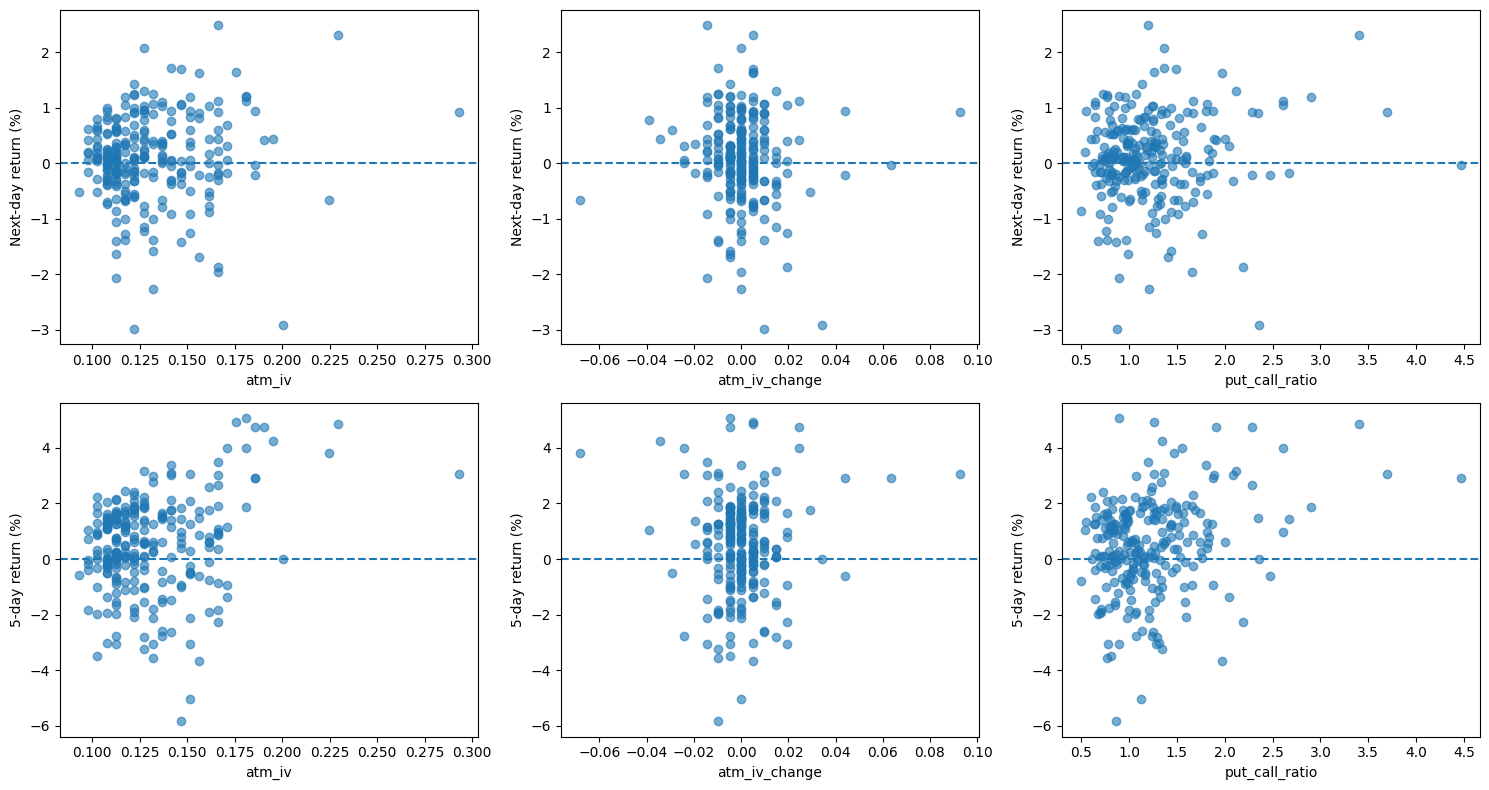

In [213]:
import matplotlib.pyplot as plt

primary_features = [
    "atm_iv",
    "atm_iv_change",
    "put_call_ratio"
]

targets = [
    ("next_day_return", "Next-day return (%)"),
    ("next_5d_return", "5-day return (%)")
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, (target, ylabel) in enumerate(targets):

    for j, feature in enumerate(primary_features):

        ax = axes[i, j]

        ax.scatter(
            model_data[feature],
            100 * model_data[target],
            alpha=0.6
        )

        ax.axhline(0, linestyle="--")
        ax.set_xlabel(feature)
        ax.set_ylabel(ylabel)

plt.tight_layout()
plt.show()


The scatter plots show substantial noise and no strong univariate linear relationship between any individual predictor and next-day return. ATM IV takes visibly discrete values because of the quantization of implied volatility in the source dataset.

## Next-day return distribution

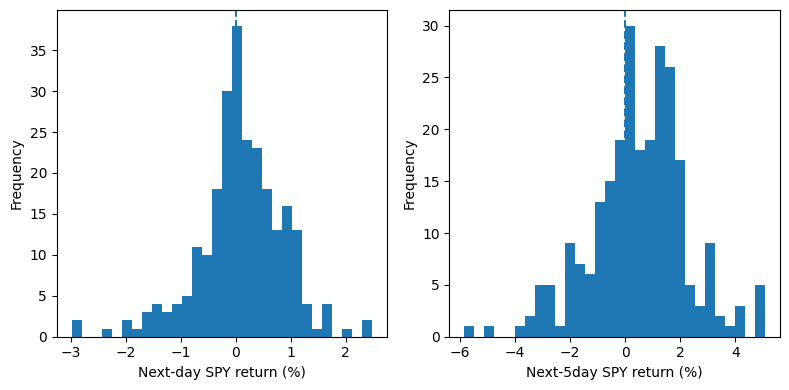

In [214]:
# plt.figure(figsize=(8, 4))

targets = [("next_day_return", "Next-day SPY return (%)"),
          ("next_5d_return", "Next-5day SPY return (%)")]
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (feature, y_label) in zip(axes, targets):
  ax.hist(
      100 * model_data[feature],
      bins=30
  )

  ax.axvline(0, linestyle="--")

  ax.set_xlabel(y_label)
  ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


**Remark**: Next-day returns are concentrated around zero, illustrating why a zero-return forecast provides a meaningful simple benchmark.

# Baseline and Validation Design



## Zero-Return Baseline
Daily equity returns are noisy and concentrated around zero. A forecasting model should therefore be evaluated relative to a simple benchmark rather than by prediction error alone. I use a zero-return forecast,
$$
\hat{r}_{t+1}^{baseline}=0,
$$
which gives
$$
MSE_{baseline}
=
\frac{1}{N}\sum_{t=1}^{N}r_{t+1}^2.
$$
A model that does not improve upon this benchmark provides little evidence that its additional complexity contributes useful forecasting information.

## Train/Test split and Exanding-Window design

**Chronological Validation**: Because the observations form a time series, randomly splitting dates into training and test sets can allow future observations to influence a model used to predict earlier observations. Instead, I preserve chronological ordering so that every prediction is generated using only information available before the prediction period.

More precisely, I use an expanding-window validation procedure beginning in July. For each test month, the model is estimated using all observations from the beginning of the year through the preceding month. The fitted model then generates predictions for the next month. Afterward, that month's observations are incorporated into the training set for the subsequent forecast.
This mimics a sequential forecasting setting while retaining as much training data as possible given the relatively small one-year sample.

## Define the primary model
The primary specification uses three predictors: ATM IV, the daily change in ATM IV, and the filtered put/call volume ratio. I estimate the model using ordinary least squares (OLS):
$$r_{t+1}
=
\beta_0+
\beta_1 IV_t+
\beta_2\Delta IV_t+
\beta_3PCR_t+
\epsilon_{t+1}.$$
Volatility skew is considered separately as an exploratory extension.

In [215]:
import statsmodels.api as sm

def expanding_window_evaluation(model_data, features, target, nonoverlap = False):
  results = []
  all_predictions = []

  if nonoverlap and target == "next_5d_return":
    model_data = (
        model_data
        .sort_values("date")
        .reset_index(drop=True)
        .iloc[::5]
        .copy()
    )
  # Determine when the target becomes observable
  if target == "next_day_return":
      target_end_col = "target_1d_end_date"
  elif target == "next_5d_return":
      target_end_col = "target_5d_end_date"
  else:
      raise ValueError("Unknown target")

  for test_month in range(7, 13):

      month_test = model_data[
          model_data["month"] == test_month].copy()

      test_start_date = month_test["date"].min()

      month_train = model_data[
          (model_data["month"] < test_month)
          & (model_data[target_end_col] < test_start_date)].copy()

      X_train = month_train[features]
      y_train = month_train[target]

      X_test = month_test[features]
      y_test = month_test[target]

      X_train = sm.add_constant(X_train)
      X_test = sm.add_constant(X_test)

      model = sm.OLS(y_train, X_train).fit()
      pred = model.predict(X_test)

      model_mse = ((y_test - pred) ** 2).mean()
      baseline_mse = (y_test ** 2).mean()
      pred_corr = pred.corr(y_test)
      result = {
          "month": test_month,
          "n_test": len(X_test),
          "model_mse": model_mse,
          "baseline_mse": baseline_mse,
          "prediction_corr": pred_corr
      }

      for feature in features:
        result["beta_" + feature] = model.params[feature]

      results.append(result)

      month_predictions = pd.DataFrame({
      "date": month_test["date"].values,
      "actual": y_test.values,
      "predicted": pred.values })

      all_predictions.append(month_predictions)

  monthly_results = pd.DataFrame(results)

  oos_predictions = pd.concat(
    all_predictions,
    ignore_index=True)

  return monthly_results, oos_predictions


In [216]:
def all_results_predictions(model_data, features, targets, nonoverlap):
  all_monthly_results = []
  all_predictions = []

  for target, n in zip(targets, nonoverlap):
    m_results, oos_pred = expanding_window_evaluation(model_data, features, target, n)

    all_monthly_results.append(m_results)
    all_predictions.append(oos_pred)

  return all_monthly_results, all_predictions

In [217]:
features = [
    "atm_iv",
    "atm_iv_change",
    "put_call_ratio"
]
model_data["month"] = (model_data["date"].dt.month)
targets = ["next_day_return", "next_5d_return", "next_5d_return"]
nonoverlap = [False, False, True]

all_monthly_results, all_predictions = all_results_predictions(model_data, features, targets, nonoverlap)


# Primary Model Results

## Aggregate out-of-sample performance

In [218]:
def combined_mse(oos_predictions):
  combined_model_mse = ((oos_predictions["actual"]
      - oos_predictions["predicted"]) ** 2).mean()

  combined_baseline_mse = (
      oos_predictions["actual"] ** 2).mean()
  return combined_model_mse, combined_baseline_mse

def combined_corr(oos_predictions):
  combined_corr = (
      oos_predictions["predicted"]
      .corr(oos_predictions["actual"]))
  return combined_corr

def aggregate_mse_corr(cases, all_predictions):
  data = {"Target": cases,
          "MSE": [],
          "Baseline_MSE": [],
          "Prediction_Correlation": []}
  for oos_pred in all_predictions:
      primary_mse, baseline_mse = combined_mse(oos_pred)
      primary_corr = combined_corr(oos_pred)
      data["MSE"].append(primary_mse)
      data["Baseline_MSE"].append(baseline_mse)
      data["Prediction_Correlation"].append(primary_corr)

  agg_primary_mse_corr = pd.DataFrame(data)

  return agg_primary_mse_corr

def add_mse_improvement(agg_mse_corr):
    result = agg_mse_corr.copy()

    result["MSE_Improvement"] = (
        result["Baseline_MSE"] - result["MSE"]
    ) / result["Baseline_MSE"]

    return result

In [219]:
cases = ["next_day_return", "next_5d_return", "next_5d_return_nonoverlap"]
agg_primary_mse_corr = aggregate_mse_corr(cases, all_predictions)
agg_performance = add_mse_improvement(agg_primary_mse_corr)

display(agg_performance.style.format({
        "MSE": "{:.8f}",
        "Baseline_MSE": "{:.8f}",
        "MSE_Improvement": "{:.2%}",
        "Prediction_Correlation": "{:.3f}"}))


,Target,MSE,Baseline_MSE,Prediction_Correlation,MSE_Improvement
0,next_day_return,0.00007963,0.00007962,0.095,-0.01%
1,next_5d_return,0.00040604,0.00042719,0.230,4.95%
2,next_5d_return_nonoverlap,0.00042907,0.00039555,0.044,-8.47%


**Remarks on Aggregated Performance**

The three-feature model shows little out-of-sample predictive performance at the one-day horizon. Its MSE is essentially identical to the zero-return baseline, while the prediction correlation is modestly positive at 0.095.

Performance appears stronger for overlapping five-day forward returns. The model reduces MSE by approximately 4.95% relative to the baseline and achieves a prediction correlation of 0.230. However, adjacent five-day forward returns share four trading days, so these observations are not independent and the apparent improvement may overstate the robustness of the predictive relationship.

When the analysis is repeated using non-overlapping five-day return windows, the improvement disappears: the model underperforms the baseline by approximately 8.47%, while prediction correlation falls to 0.044. The contrast between the overlapping and non-overlapping specifications suggests that the stronger five-day result is sensitive to the construction of the return horizon and should not be interpreted as robust evidence of out-of-sample predictability.

## Predicted vs. Actual Return plots

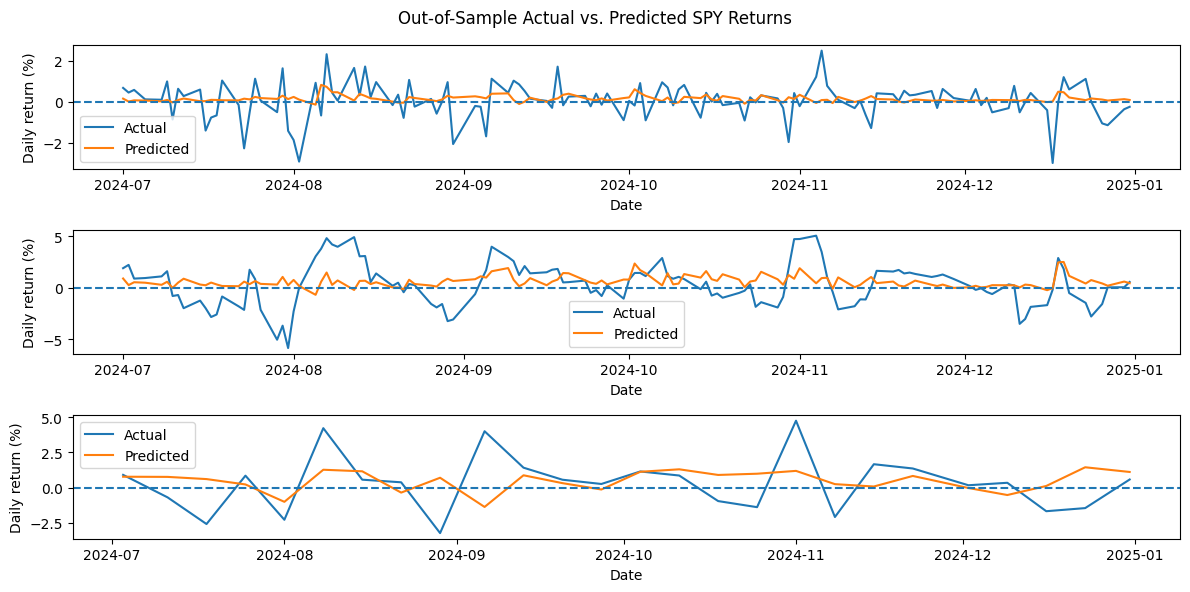

In [220]:
fig, axes = plt.subplots(3,1, figsize=(12, 6))
for ax, oos_pred in zip(axes, all_predictions):
  ax.plot(
      oos_pred["date"],
      100 * oos_pred["actual"],
      label="Actual"
  )

  ax.plot(
      oos_pred["date"],
      100 * oos_pred["predicted"],
      label="Predicted"
  )

  ax.axhline(0, linestyle="--")

  ax.set_xlabel("Date")
  ax.set_ylabel("Daily return (%)")
  ax.legend()

fig.suptitle("Out-of-Sample Actual vs. Predicted SPY Returns")


plt.tight_layout()
plt.show()

**Remarks on Predicted vs. Actual Returns.** The predicted returns exhibit substantially less variation than realized returns across all three specifications, indicating that the linear model generally does not capture the magnitude of large SPY movements. At the next-day horizon, predictions remain concentrated near zero, consistent with the weak aggregate predictive performance.
The overlapping five-day specification shows greater apparent co-movement between predicted and realized returns. However, consecutive five-day targets share four trading days, which mechanically introduces persistence into the realized-return series. When the analysis is restricted to non-overlapping five-day windows, the sample becomes substantially smaller and the visual relationship between predicted and realized returns weakens. This is consistent with the deterioration observed in the aggregate robustness results.

## Monthly MSE and Prediction Correlation

In [221]:
def display_monthly_mse_corr(cases, columns, all_monthly_results):
  merged_df = all_monthly_results[0][["month", "n_test"] + columns]
  merged_df.columns = ["month", "n_test"] + [col + "_" + cases[0] for col in columns]

  for c, df in zip(cases[1:], all_monthly_results[1:]):
    df = df[["month"] + columns]
    df.columns = ["month"] + [col + "_" + c for col in columns]
    merged_df = pd.merge(merged_df, df, on='month', how='inner')
  return merged_df

cases = ["1d", "5d", "5d_nonoverlap"]
columns = ["model_mse", "baseline_mse", "prediction_corr"]

all_monthly_mse_corr = display_monthly_mse_corr(cases, columns, all_monthly_results)
all_monthly_mse_corr

,month,n_test,model_mse_1d,baseline_mse_1d,prediction_corr_1d,model_mse_5d,baseline_mse_5d,prediction_corr_5d,model_mse_5d_nonoverlap,baseline_mse_5d_nonoverlap,prediction_corr_5d_nonoverlap
0,7,22,0.000085,0.000087,0.268788,0.000697,0.000585,0.077362,0.000317,0.000217,-0.237898
1,8,22,0.000147,0.000150,0.165300,0.000695,0.000732,-0.016430,0.000533,0.000678,0.521277
2,9,20,0.000054,0.000054,-0.068698,0.000149,0.000279,0.375027,0.000734,0.000462,-0.742184
3,10,23,0.000048,0.000044,0.058758,0.000269,0.000248,0.109264,0.000232,0.000122,0.810241
4,11,20,0.000064,0.000061,-0.393174,0.000332,0.000457,0.336761,0.000523,0.000789,0.708778
5,12,21,0.000077,0.000079,0.364871,0.000263,0.000252,0.572592,0.000254,0.000107,-0.276961


Monthly Performance. Out-of-sample performance varies considerably across months. At the next-day horizon, prediction correlations alternate between positive and negative values, and MSE improvements relative to the zero-return baseline are inconsistent, indicating limited temporal stability in the predictive relationship.
The overlapping five-day specification exhibits more consistently positive prediction correlations, particularly from September onward, but MSE improvements remain uneven across months. Thus, the stronger aggregate five-day performance is not uniformly distributed throughout the evaluation period.
Monthly statistics for the non-overlapping five-day specification are substantially more volatile because each month contains only a small number of non-overlapping observations. Individual monthly correlations are therefore not interpreted as reliable measures of predictive performance; the pooled out-of-sample metrics provide a more informative robustness comparison.

## Coefficient stability across months

In [222]:
def display_all_monthly_betas(cases, features, all_monthly_results):

  merged_df = all_monthly_results[0][["month"]+["beta_"+feature for feature in features]]
  merged_df.columns = ["month"]+["beta_"+feature+"_"+cases[0] for feature in features]
  for c, df in zip(cases[1:], all_monthly_results[1:]):

      df = df[["month"] + ["beta_"+feature for feature in features]]
      df.columns = ["month"] + ["beta_"+feature + "_" + c for feature in features]

      merged_df = pd.merge(merged_df, df, on='month', how='inner')

  return merged_df

cases = ["1d", "5d", "5d_nonoverlap"]
features = ["atm_iv", "atm_iv_change", "put_call_ratio"]

all_monthly_betas = display_all_monthly_betas(cases, features, all_monthly_results)
all_monthly_betas

,month,beta_atm_iv_1d,beta_atm_iv_change_1d,beta_put_call_ratio_1d,beta_atm_iv_5d,beta_atm_iv_change_5d,beta_put_call_ratio_5d,beta_atm_iv_5d_nonoverlap,beta_atm_iv_change_5d_nonoverlap,beta_put_call_ratio_5d_nonoverlap
0,7,0.003379,-0.049519,0.002124,-0.098906,-0.148182,0.010201,0.047768,-0.062698,-0.010277
1,8,-0.011175,-0.102159,0.003399,-0.150676,-0.177136,0.011714,-0.047535,-0.364958,-0.005386
2,9,-0.029552,-0.071947,0.004216,-0.010862,-0.318354,0.013050,0.053633,-0.698108,-0.003478
3,10,-0.016536,-0.052915,0.003529,0.032705,-0.299392,0.011724,0.213169,-0.269875,-0.004417
4,11,-0.015095,-0.028609,0.002905,0.028320,-0.230033,0.010446,0.216126,-0.208044,-0.006307
5,12,0.009810,-0.035656,0.001671,0.091114,-0.204396,0.008389,0.296514,-0.149888,-0.008033


In [223]:
import matplotlib.pyplot as plt

def plot_monthly_betas(all_monthly_betas, cases, features):

    case_labels = {
        "1d": "Next-day",
        "5d": "5-day overlapping",
        "5d_nonoverlap": "5-day non-overlapping"
    }

    feature_labels = {
        "atm_iv": "ATM IV",
        "atm_iv_change": "ATM IV Change",
        "put_call_ratio": "Put/Call Ratio"
    }

    fig, axes = plt.subplots(
        len(features), 1,
        figsize=(6, 6),
        sharex=True
    )

    for ax, feature in zip(axes, features):

        for case in cases:
            column = f"beta_{feature}_{case}"

            ax.plot(
                all_monthly_betas["month"],
                all_monthly_betas[column],
                marker="o",
                label=case_labels[case]
            )

        # Zero reference line
        ax.axhline(0, linestyle="--", linewidth=1)

        ax.set_ylabel("Coefficients")
        ax.set_title(
            f"{feature_labels[feature]} Coefficient Stability"
        )

        ax.legend()

    # Month labels
    month_labels = ["Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    axes[-1].set_xticks(all_monthly_betas["month"])
    axes[-1].set_xticklabels(month_labels)
    axes[-1].set_xlabel("Test Month")

    plt.tight_layout()
    plt.show()

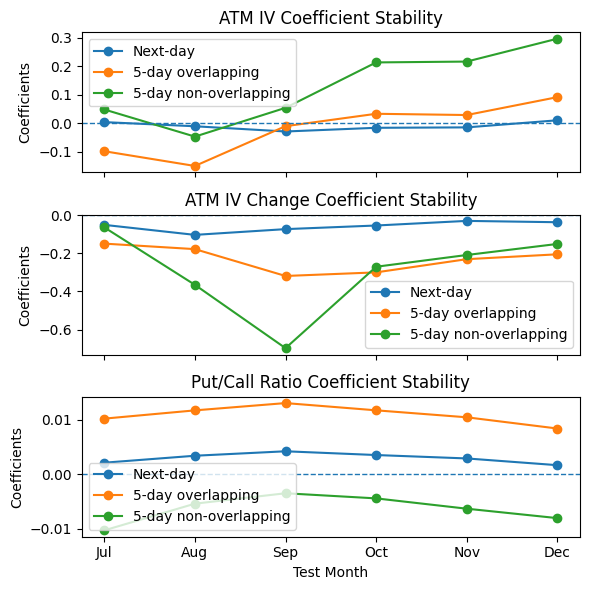

In [224]:
plot_monthly_betas(
    all_monthly_betas,
    cases,
    features
)

The expanding-window coefficient estimates show differing degrees of stability across the three predictors. The coefficient on the level of ATM implied volatility changes sign as the training sample expands, providing little evidence of a stable directional relationship.
In contrast, the coefficient on the daily change in ATM implied volatility remains negative across all expanding-window fits and all three target specifications. The put/call volume ratio also has a stable positive sign in the next-day and overlapping five-day models, although its sign reverses in the non-overlapping five-day specification. This sensitivity to the sampling construction cautions against interpreting the coefficient signs as robust economic relationships.
Because successive expanding-window models share most of their training observations, these coefficient paths should be interpreted as diagnostics of parameter stability as new data are incorporated rather than as independent coefficient estimates.

# Volatility-Skew Extension

## Motivation

**Volatility-Skew Extension** The primary model uses ATM IV, the change in ATM IV, and the put/call volume ratio. As an exploratory extension, I test whether the 25-delta volatility skew constructed earlier contains additional information about subsequent returns.
The extended specification is
$$
r_{t+1}
=
\beta_0+\beta_1IV_t+\beta_2\Delta IV_t
+\beta_3PCR_t+\beta_4Skew_t+\epsilon_{t+1}.
$$ Because skew is moderately correlated with both ATM IV and PCR, the relevant question is not simply whether skew is individually correlated with next-day returns, but whether it improves out-of-sample forecasts conditional on the existing predictors.

In [225]:
extended_features = [
    "atm_iv",
    "atm_iv_change",
    "put_call_ratio",
    "skew"
]

targets = ["next_day_return", "next_5d_return", "next_5d_return"]
nonoverlap = [False, False, True]

all_skew_monthly_results, all_skew_predictions = all_results_predictions(model_data, extended_features, targets, nonoverlap)



## Aggregate out-of-sample performance

In [226]:
cases = ["next_day_return", "next_5d_return", "next_5d_return_nonoverlap"]
agg_skew_mse_corr = aggregate_mse_corr(cases, all_skew_predictions)
agg_skew_performance = add_mse_improvement(agg_skew_mse_corr)

display(agg_skew_performance.style.format({
        "MSE": "{:.8f}",
        "Baseline_MSE": "{:.8f}",
        "MSE_Improvement": "{:.2%}",
        "Prediction_Correlation": "{:.3f}"}))


,Target,MSE,Baseline_MSE,Prediction_Correlation,MSE_Improvement
0,next_day_return,0.00007973,0.00007962,0.088,-0.14%
1,next_5d_return,0.00040482,0.00042719,0.271,5.24%
2,next_5d_return_nonoverlap,0.00041615,0.00039555,0.167,-5.21%


**Remarks on Volatility-Skew Extension.** Adding 25-delta volatility skew produces little change in next-day forecasting performance: prediction correlation decreases slightly from 0.095 to 0.088, while the model continues to perform approximately in line with the zero-return MSE baseline.
At the overlapping five-day horizon, the skew-extended model shows modest improvement, increasing prediction correlation from 0.230 to 0.271 and MSE improvement from 4.95% to 5.24%. For non-overlapping five-day returns, correlation also increases from 0.044 to 0.167 and the MSE shortfall relative to baseline narrows, but the model still underperforms the baseline by 5.21%.
Overall, volatility skew provides some incremental predictive information at the five-day horizon, particularly as measured by prediction correlation, but does not alter the broader conclusion that out-of-sample return predictability is limited and sensitive to target construction.

## Skew coefficient stability across months

In [227]:
cases = ["1d", "5d", "5d_nonoverlap"]
features = ["skew"]

all_monthly_skew_beta = display_all_monthly_betas(cases, features, all_skew_monthly_results)
all_monthly_skew_beta

,month,beta_skew_1d,beta_skew_5d,beta_skew_5d_nonoverlap
0,7,-0.033792,0.032443,0.275850
1,8,0.000183,0.028578,0.332420
2,9,-0.003677,0.162683,0.342942
3,10,-0.020944,0.076998,0.435511
4,11,-0.029081,0.072811,0.408169
5,12,-0.022934,0.071666,0.327746


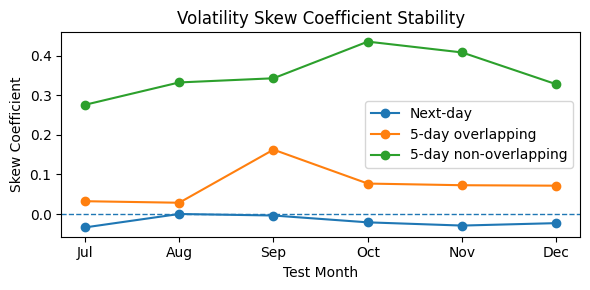

In [228]:
plt.figure(figsize=(6, 3))

for case in cases:
    plt.plot(
        all_monthly_skew_beta["month"],
        all_monthly_skew_beta[f"beta_skew_{case}"],
        marker="o",
        label={
            "1d": "Next-day",
            "5d": "5-day overlapping",
            "5d_nonoverlap": "5-day non-overlapping"
        }[case]
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.xticks(
    all_monthly_skew_beta["month"],
    ["Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

plt.xlabel("Test Month")
plt.ylabel("Skew Coefficient")
plt.title("Volatility Skew Coefficient Stability")
plt.legend()

plt.tight_layout()
plt.show()

Skew Coefficient Stability. The estimated skew coefficient is small and generally negative in the next-day model, while it remains positive across all expanding-window fits for both five-day specifications. The positive sign also persists when the five-day target is restricted to non-overlapping observations.
This coefficient stability does not, however, translate into robust out-of-sample forecasting performance. Although adding skew improves prediction correlation at the five-day horizon, the non-overlapping model continues to underperform the zero-return MSE baseline. The results therefore suggest that skew contains some incremental information in the fitted five-day models, but its contribution is insufficient to establish robust return predictability.

# Limitations and Conclusion


## Key findings

This project examined whether simple signals derived from the SPY options market contain information about subsequent SPY returns. The primary model used near-30-day ATM implied volatility, changes in ATM implied volatility, and a filtered put/call volume ratio, with 25-delta volatility skew considered as an additional feature.
Out-of-sample results provide limited evidence of short-horizon return predictability. At the next-day horizon, both the primary and skew-extended models perform approximately in line with the zero-return MSE baseline and exhibit only weak prediction correlations. Results are more favorable for overlapping five-day forward returns: the primary model reduces MSE by approximately 4.95% relative to baseline, while adding volatility skew increases this improvement modestly to 5.24% and raises prediction correlation from 0.230 to 0.271.
However, consecutive five-day forward returns share four trading days. When the analysis is repeated using non-overlapping five-day windows, the apparent forecasting improvement is substantially weaker: both models underperform the zero-return MSE baseline. Adding volatility skew improves prediction correlation and reduces the MSE shortfall, but does not overturn this result. Together with variation in performance across evaluation months, these findings suggest that the observed predictive relationships are sensitive to the construction of the return horizon and are not sufficiently robust to establish reliable out-of-sample return predictability.

## Limitations
There are several limitations of this study.


1.   **Sample size limitations.** The analysis uses only 2024 data, providing a relatively short sample that may not represent different volatility and market regimes. This limitation is particularly important for the non-overlapping five-day analysis, where removing overlapping observations substantially reduces the effective sample size.

2.   **Coarse implied volatility.** The available implied-volatility data are relatively coarse, and the near-30-day features use the listed expiration closest to 30 days rather than an interpolated constant-maturity option surface.

3. **Timing issue.** Options features are also constructed from daily end-of-day observations without precise intraday timestamps; the results should therefore be interpreted as a predictive statistical analysis rather than an immediately executable trading strategy.

4. **Model limitations.** The linear specification captures only simple relationships among a small set of options-market signals and subsequent returns.

## Possible Extensions
With the limitations being identified, one can try the following things as next steps.

1.   **Evaluate across multiple market regimes.** Freeze the current feature definitions and validation procedure, then test them on additional years of data to determine whether the weak predictive relationship persists.
2.   **Improve volatility-surface construction.** Construct exact constant-maturity ATM volatility and delta-based skew using interpolation across expirations and strikes rather than nearest-contract approximations.
3.  **Study alternative prediction targets.** Options-market signals could be evaluated for forecasting realized volatility or other measures of future return distributions rather than only conditional mean returns, which may align more directly with the information embedded in option prices.